# Vergleichende Evaluation: PPO vs. DPO vs. SFT vs. Few-Shot Baseline

Dieses Notebook führt eine umfassende empirische und linguistische Analyse des **PPO-Experiments (Proximal Policy Optimization)** im Vergleich zu **DPO (Direct Preference Optimization)**, **SFT (Supervised Fine-Tuning)** und der **Few-Shot Baseline** durch.

### Untersuchte Dimensionen:
1. **Online-RL (PPO) vs. Offline-Präferenzlernen (DPO):**
   * Wie verhält sich die dynamische Exploration während des Online-Rollouts im Vergleich zum Lernen auf statischen Präferenzpaaren?
2. **Architekturvergleich:**
   * *Decoder-Only (Qwen 2.5 1.5B)* vs. *Encoder-Decoder (mBART-50)*
3. **Pareto-Front & Zielkonflikt:**
   * Maximierung der linguistischen Einfachheit ($R_{\text{style}}$) bei gleichzeitiger Wahrung der inhaltlichen Faktentreue ($R_{\text{sem}}$).
4. **Linguistische Leitplanken (Regeln W2–W11):**
   * Abbau von Passivkonstruktionen, Genitiv-Eliminierung, Nominalstil-Vermeidung und Satzlängenverkürzung.

In [1]:
import os
import sys
import json
import glob
from typing import List, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def find_repo_root():
    p = os.path.abspath(os.getcwd())
    while p != os.path.dirname(p):
        if os.path.exists(os.path.join(p, "data")) and os.path.exists(os.path.join(p, "results")):
            return p
        p = os.path.dirname(p)
    return os.path.abspath(os.path.expanduser("~/Documents/Master Thesis"))

REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

print("Arbeitsverzeichnis:", os.getcwd())

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 150


Arbeitsverzeichnis: /Users/fietescheel/Documents/Master Thesis


## 1. Laden der Benchmark-Daten (7-Wege-Vergleich)

In [2]:
csv_path = "results/evaluation/benchmark_ppo_vs_dpo_vs_sft_7way.csv"
summary_path = "results/evaluation/master_benchmark_summary_7way.csv"

if os.path.exists(csv_path):
    df_bench = pd.read_csv(csv_path)
    print(f"Erfolgreich geladen: {len(df_bench)} Datensätze aus {csv_path}")
    print("Vorhandene Modelle:", df_bench["model"].unique().tolist())
else:
    print(f"Hinweis: {csv_path} existiert noch nicht. Bitte starte zuerst das Benchmark-Skript!")
    df_bench = pd.DataFrame()

if os.path.exists(summary_path):
    df_summary = pd.read_csv(summary_path)
    display(df_summary)


Erfolgreich geladen: 259 Datensätze aus results/evaluation/benchmark_ppo_vs_dpo_vs_sft_7way.csv
Vorhandene Modelle: ['Few-Shot Baseline (Qwen)', 'Decoder-Only SFT (Qwen)', 'Decoder-Only DPO (Qwen)', 'Decoder-Only PPO (Qwen)', 'Encoder-Decoder SFT (mBART)', 'Encoder-Decoder DPO (mBART)', 'Encoder-Decoder PPO (mBART)']


,Model,BiLSTM Simplicity,SBERT Similarity,Composite Reward,Flesch-DE (↑),LIX (↓),Wiener Sachtext (↓),BLEU-4,ROUGE-L F1,Compression Ratio,Passiv-Ratio,Genitiv-Ratio,Nominal-Ratio
0,Few-Shot Baseline (Qwen),0.206 ± 0.10,0.738 ± 0.09,0.472 ± 0.07,33.2 ± 18.4,48.0 ± 11.6,11.23 ± 3.16,0.003 ± 0.01,0.091 ± 0.03,0.28 ± 0.18,0.170,0.031,0.021
1,Decoder-Only SFT (Qwen),0.742 ± 0.14,0.582 ± 0.14,0.662 ± 0.11,49.8 ± 12.8,34.5 ± 5.3,7.98 ± 1.79,0.002 ± 0.00,0.099 ± 0.04,0.36 ± 0.28,0.081,0.008,0.013
2,Decoder-Only DPO (Qwen),0.735 ± 0.12,0.516 ± 0.17,0.625 ± 0.10,52.9 ± 10.7,35.4 ± 5.4,7.76 ± 1.91,0.001 ± 0.00,0.091 ± 0.04,0.35 ± 0.28,0.090,0.005,0.011
3,Decoder-Only PPO (Qwen),0.150 ± 0.09,0.233 ± 0.19,0.192 ± 0.11,-128.3 ± 130.4,188.7 ± 77.1,31.62 ± 10.90,0.000 ± 0.00,0.015 ± 0.02,0.20 ± 0.16,0.007,0.046,0.001
4,Encoder-Decoder SFT (mBART),0.402 ± 0.22,0.727 ± 0.16,0.564 ± 0.11,26.5 ± 16.6,47.5 ± 7.0,11.55 ± 1.97,0.004 ± 0.02,0.111 ± 0.06,0.31 ± 0.29,0.100,0.024,0.055
5,Encoder-Decoder DPO (mBART),0.311 ± 0.19,0.130 ± 0.11,0.220 ± 0.15,112.5 ± 20.0,86.7 ± 25.8,7.95 ± 1.95,0.000 ± 0.00,0.022 ± 0.05,0.12 ± 0.13,0.002,0.000,0.001
6,Encoder-Decoder PPO (mBART),0.144 ± 0.07,0.919 ± 0.06,0.532 ± 0.05,20.8 ± 17.5,54.8 ± 7.9,13.24 ± 2.30,0.016 ± 0.04,0.139 ± 0.07,0.38 ± 0.29,0.267,0.075,0.048


## 2. Pareto-Frontier: Einfachheit vs. Inhaltstreue

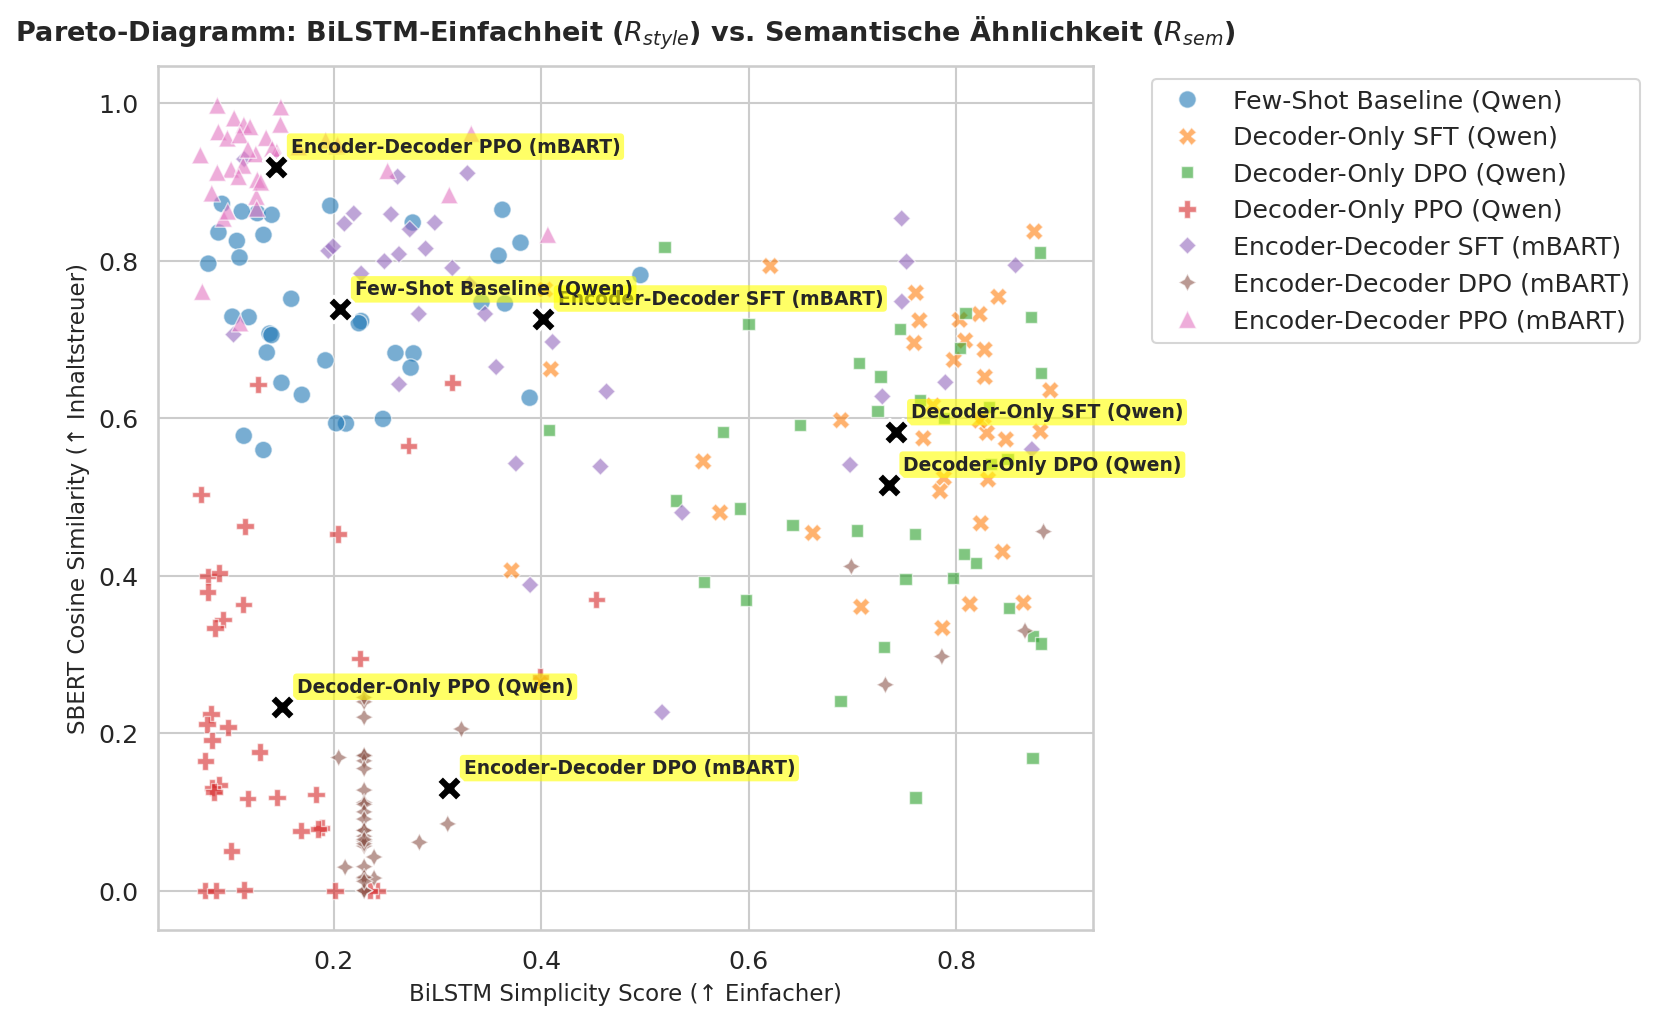

In [3]:
if not df_bench.empty:
    plt.figure(figsize=(11, 7))
    
    palette = sns.color_palette("tab10", n_colors=len(df_bench["model"].unique()))
    sns.scatterplot(
        data=df_bench,
        x="bilstm_style",
        y="sbert_sim",
        hue="model",
        style="model",
        s=70,
        alpha=0.6,
        palette=palette
    )
    
    # Aggregierte Modellmittelwerte als Schwerpunkte einzeichnen
    means = df_bench.groupby("model")[["bilstm_style", "sbert_sim"]].mean().reset_index()
    for _, row in means.iterrows():
        plt.scatter(
            row["bilstm_style"], row["sbert_sim"],
            color="black", marker="X", s=160, edgecolor="white", linewidth=1.5, zorder=5
        )
        plt.annotate(
            row["model"],
            (row["bilstm_style"], row["sbert_sim"]),
            textcoords="offset points",
            xytext=(7, 7),
            fontsize=9,
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.2", fc="yellow", alpha=0.6, ec="none")
        )
        
    plt.title("Pareto-Diagramm: BiLSTM-Einfachheit ($R_{style}$) vs. Semantische Ähnlichkeit ($R_{sem}$)", fontsize=13, fontweight="bold", pad=12)
    plt.xlabel("BiLSTM Simplicity Score (↑ Einfacher)", fontsize=11)
    plt.ylabel("SBERT Cosine Similarity (↑ Inhaltstreuer)", fontsize=11)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", frameon=True)
    plt.tight_layout()
    plt.show()


## 3. Verteilungsanalyse der Lesbarkeitsmetriken (Flesch & LIX)

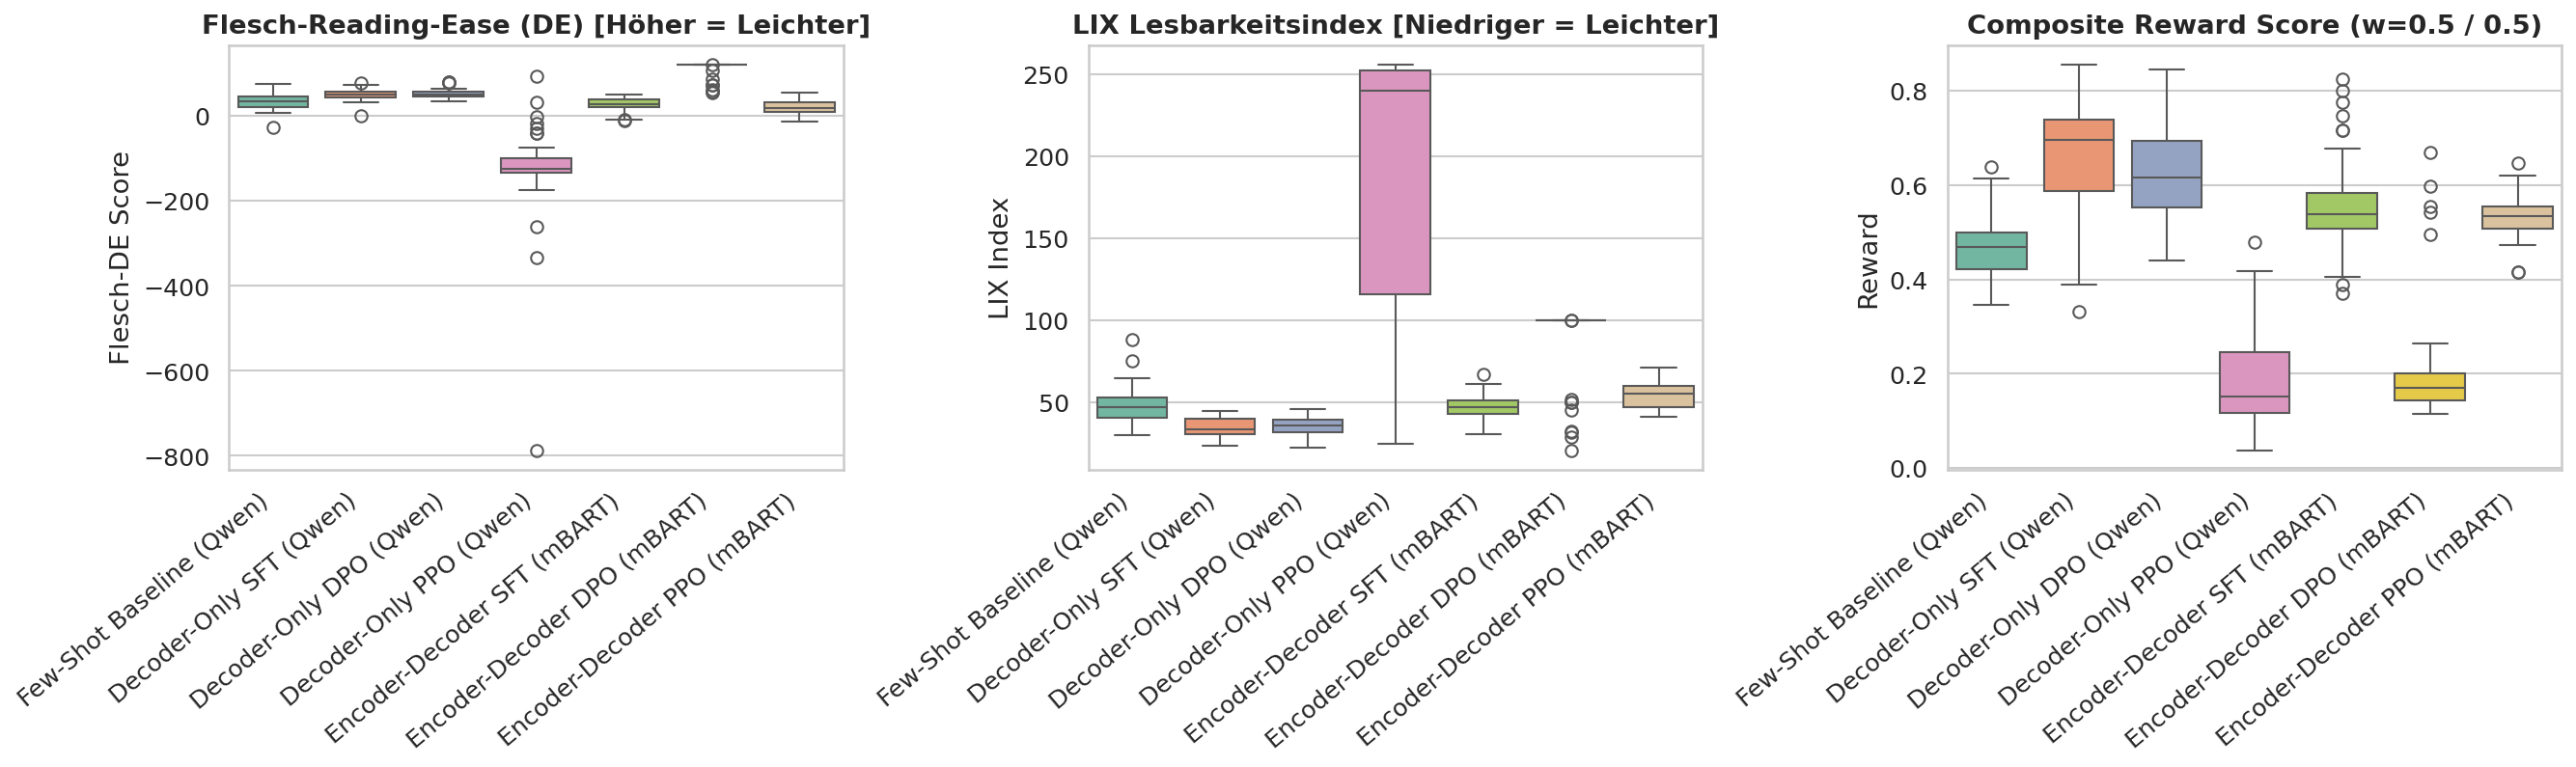

In [4]:
if not df_bench.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    
    # Flesch Reading Ease (DE)
    sns.boxplot(data=df_bench, x="model", y="flesch_de", hue="model", legend=False, ax=axes[0], palette="Set2")
    axes[0].set_title("Flesch-Reading-Ease (DE) [Höher = Leichter]", fontweight="bold")
    plt.setp(axes[0].get_xticklabels(), rotation=40, ha="right")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Flesch-DE Score")
    
    # LIX Lesbarkeitsindex
    sns.boxplot(data=df_bench, x="model", y="lix", hue="model", legend=False, ax=axes[1], palette="Set2")
    axes[1].set_title("LIX Lesbarkeitsindex [Niedriger = Leichter]", fontweight="bold")
    plt.setp(axes[1].get_xticklabels(), rotation=40, ha="right")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("LIX Index")
    
    # Composite Reward
    sns.boxplot(data=df_bench, x="model", y="composite_reward", hue="model", legend=False, ax=axes[2], palette="Set2")
    axes[2].set_title("Composite Reward Score (w=0.5 / 0.5)", fontweight="bold")
    plt.setp(axes[2].get_xticklabels(), rotation=40, ha="right")
    axes[2].set_xlabel("")
    axes[2].set_ylabel("Reward")
    
    plt.tight_layout()
    plt.show()


## 4. Linguistische Regeltreue (Leitplanken W2–W11)

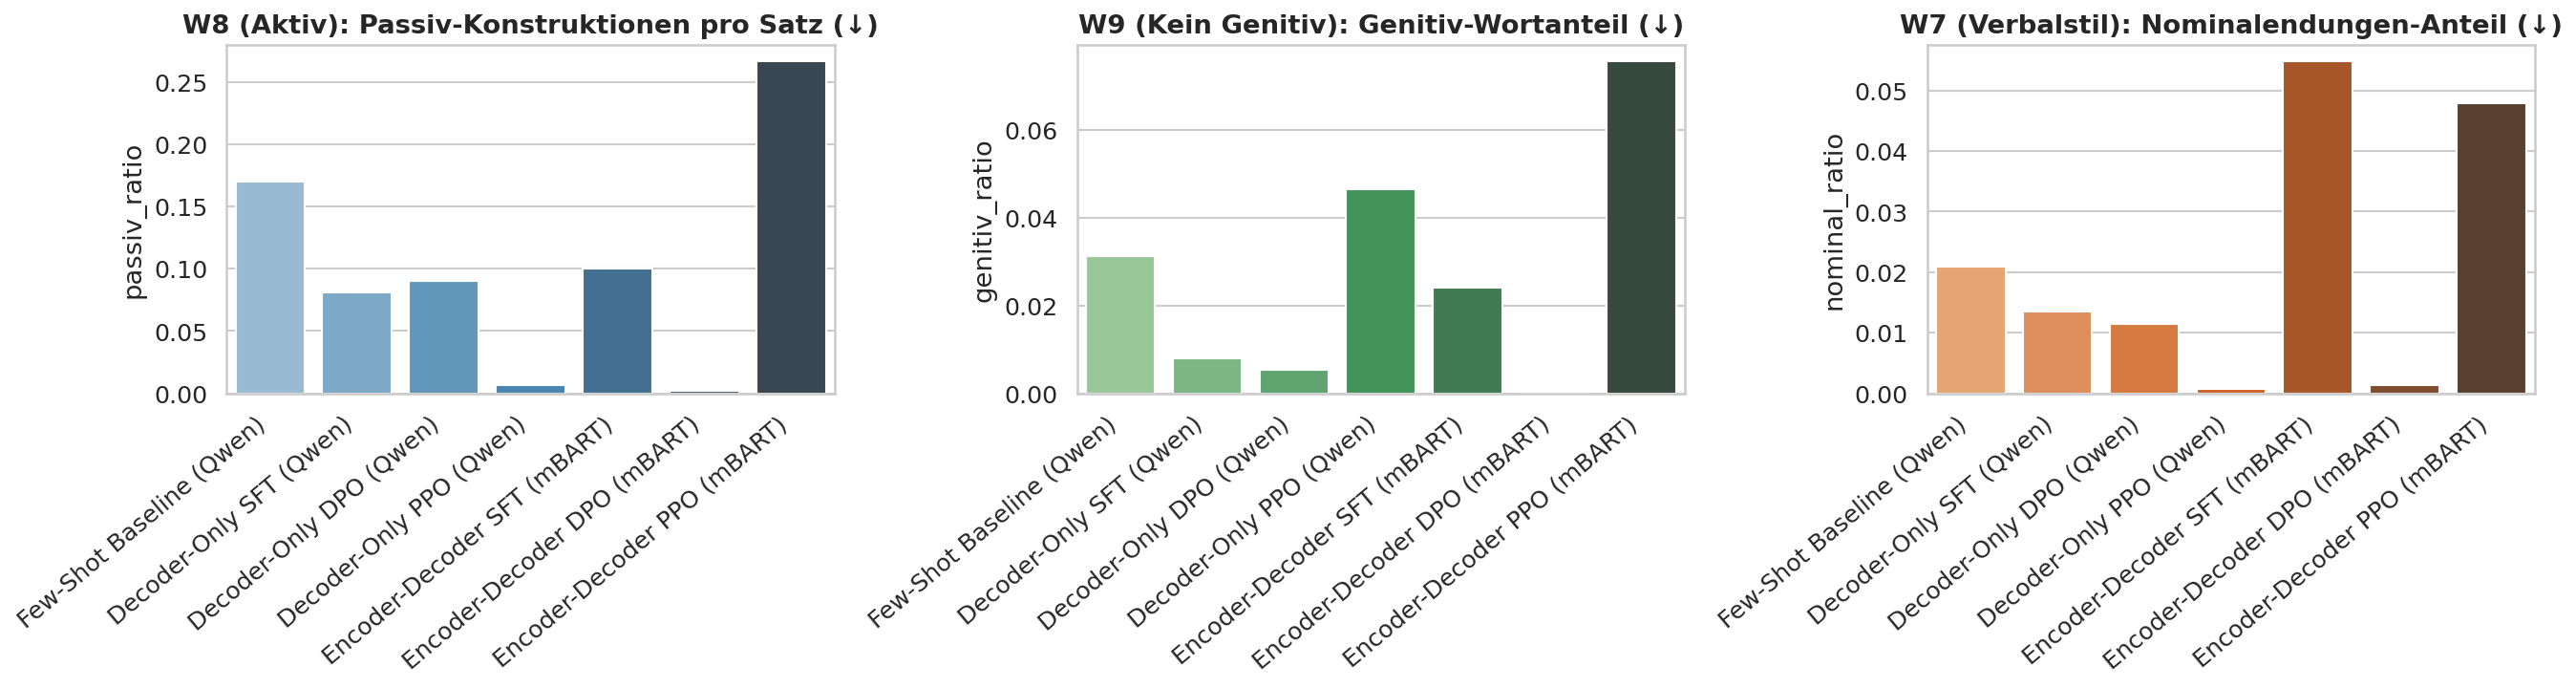

In [5]:
if not df_bench.empty and "passiv_ratio" in df_bench.columns:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Passiv-Anteil
    sns.barplot(data=df_bench, x="model", y="passiv_ratio", hue="model", legend=False, ax=axes[0], palette="Blues_d", errorbar=None)
    axes[0].set_title("W8 (Aktiv): Passiv-Konstruktionen pro Satz (↓)", fontweight="bold")
    plt.setp(axes[0].get_xticklabels(), rotation=40, ha="right")
    axes[0].set_xlabel("")
    
    # Genitiv-Anteil
    sns.barplot(data=df_bench, x="model", y="genitiv_ratio", hue="model", legend=False, ax=axes[1], palette="Greens_d", errorbar=None)
    axes[1].set_title("W9 (Kein Genitiv): Genitiv-Wortanteil (↓)", fontweight="bold")
    plt.setp(axes[1].get_xticklabels(), rotation=40, ha="right")
    axes[1].set_xlabel("")
    
    # Nominalstil-Anteil
    sns.barplot(data=df_bench, x="model", y="nominal_ratio", hue="model", legend=False, ax=axes[2], palette="Oranges_d", errorbar=None)
    axes[2].set_title("W7 (Verbalstil): Nominalendungen-Anteil (↓)", fontweight="bold")
    plt.setp(axes[2].get_xticklabels(), rotation=40, ha="right")
    axes[2].set_xlabel("")
    
    plt.tight_layout()
    plt.show()


## 5. Statistische Signifikanz-Tests (Wilcoxon Signed-Rank Test)

In [6]:
if not df_bench.empty:
    models = df_bench["model"].unique().tolist()
    metric = "composite_reward"
    
    print(f"=== Paarweise Signifikanztests (Wilcoxon Signed-Rank Test für {metric}) ===\n")
    for i in range(len(models)):
        for j in range(i + 1, len(models)):
            m1, m2 = models[i], models[j]
            v1 = df_bench[df_bench["model"] == m1][metric].values
            v2 = df_bench[df_bench["model"] == m2][metric].values
            
            if len(v1) == len(v2) and len(v1) > 0:
                stat, p_val = stats.wilcoxon(v1, v2)
                diff = np.mean(v1) - np.mean(v2)
                sig = "*** (p < 0.001)" if p_val < 0.001 else ("** (p < 0.01)" if p_val < 0.01 else ("* (p < 0.05)" if p_val < 0.05 else "n.s."))
                print(f"{m1} vs. {m2}:")
                print(f"  -> Differenz: {diff:+.4f} | p-Wert: {p_val:.4e} [{sig}]\n")


=== Paarweise Signifikanztests (Wilcoxon Signed-Rank Test für composite_reward) ===

Few-Shot Baseline (Qwen) vs. Decoder-Only SFT (Qwen):
  -> Differenz: -0.1902 | p-Wert: 9.6057e-08 [*** (p < 0.001)]

Few-Shot Baseline (Qwen) vs. Decoder-Only DPO (Qwen):
  -> Differenz: -0.1532 | p-Wert: 1.9936e-09 [*** (p < 0.001)]

Few-Shot Baseline (Qwen) vs. Decoder-Only PPO (Qwen):
  -> Differenz: +0.2802 | p-Wert: 1.4552e-10 [*** (p < 0.001)]

Few-Shot Baseline (Qwen) vs. Encoder-Decoder SFT (mBART):
  -> Differenz: -0.0920 | p-Wert: 3.4010e-05 [*** (p < 0.001)]

Few-Shot Baseline (Qwen) vs. Encoder-Decoder DPO (mBART):
  -> Differenz: +0.2515 | p-Wert: 6.5047e-09 [*** (p < 0.001)]

Few-Shot Baseline (Qwen) vs. Encoder-Decoder PPO (mBART):
  -> Differenz: -0.0598 | p-Wert: 2.6359e-05 [*** (p < 0.001)]

Decoder-Only SFT (Qwen) vs. Decoder-Only DPO (Qwen):
  -> Differenz: +0.0371 | p-Wert: 4.0694e-02 [* (p < 0.05)]

Decoder-Only SFT (Qwen) vs. Decoder-Only PPO (Qwen):
  -> Differenz: +0.4704 | p-

## 6. Qualitative Stichproben-Inspektion (Side-by-Side)

In [7]:
if not df_bench.empty:
    sample_indices = [0, min(5, len(df_bench["sample_idx"].unique()) - 1)]
    
    for s_idx in sample_indices:
        sample_df = df_bench[df_bench["sample_idx"] == s_idx]
        if sample_df.empty:
            continue
            
        src_text = sample_df["source_text"].iloc[0]
        ref_text = sample_df["reference_ls"].iloc[0]
        
        print("=" * 100)
        print(f"[BEISPIEL {s_idx + 1}] AUSGANGSTEXT (Alltagssprache):")
        print(src_text)
        print("-" * 100)
        print("[GOLD-REFERENZ] (Lebenshilfe Leichte Sprache):")
        print(ref_text)
        print("-" * 100)
        print("[MODELL-ÜBERSETZUNGEN]:")
        for _, row in sample_df.iterrows():
            print(f"\n{row['model']} (Reward: {row['composite_reward']:.3f} | Style: {row['bilstm_style']:.3f} | SBERT: {row['sbert_sim']:.3f}):")
            print(row["generated_ls"])
        print("=" * 100 + "\n")


[BEISPIEL 1] AUSGANGSTEXT (Alltagssprache):
Kiel, 15.10.2020. Arbeit zweiter oder dritter Klasse?? - Positionspapier Die Rede ist in diesemFall von der Entlohnung für Menschen, die in einer Werkstatt (WfbM) arbeiten. Wichtiges Detail: Es sind die Werkstätten selbst, die diese Veränderung dringend fordern. Der Lohn der Mitarbeiter*innen mit Werkstattvertrag ist bei einem 6 – 8 Stunden Arbeitstag weit davon entfernt, auf dieser Basis ein selbstfinanziertes Leben führen zu können. Das bedeutet, dass die Menschen grundsätzlich Grundsicherung beantragen müssen, um ihren Lebensunterhalt zu bestreiten – es sei denn, sie erhalten bereits eine Erwerbsminderungsrente und können in der Werkstatt noch so viel dazu verdienen, dass es gerade zum Leben reicht. Die Pandemie-bedingten Betretungsverbote für die WfbMs und die damit aller Orten eingebrochenen Erträge machen die Auszahlung dieser Löhne nun aber auch immer schwieriger. Kurzarbeit ist nicht möglich, da es sich um ein sogenanntes „arbeitnehme